# 🌐 Network Analysis with Real-World Datasets
### Using SNAP Stanford Network Datasets

---

In this notebook we work with **two real-world network datasets** from the [Stanford Large Network Dataset Collection (SNAP)](https://snap.stanford.edu/data/):

| # | Dataset | Nodes | Edges | What It Is | Purpose |
|---|---------|-------|-------|------------|---------|
| **1** | **Facebook Ego Networks** | 4,039 | 88,234 | Social circles from Facebook | Professor-led analysis walkthrough |
| **2** | **Email-Eu-Core** | 1,005 | 25,571 | Email communication at a European research institution | Guided student exercise |

**Learning Objectives:**
- Load and explore real network datasets
- Compute and interpret structural metrics (degree, centrality, clustering)
- Visualize large-scale networks effectively
- Detect and analyze communities
- Compare real networks to theoretical models

---

## 📦 Setup

In [34]:
# Install dependencies
!pip install networkx matplotlib numpy pandas python-louvain --quiet

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from collections import Counter
import community as community_louvain  # Louvain community detection
import urllib.request
import gzip
import os
import warnings
warnings.filterwarnings('ignore')

# Plotting defaults
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print("✅ All libraries loaded!")
print(f"   NetworkX version: {nx.__version__}")

✅ All libraries loaded!
   NetworkX version: 3.6.1


---
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# PART 1: Facebook Social Network (Professor-Led Demo)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 📖 About the Dataset

This dataset comes from the paper:
> J. McAuley and J. Leskovec. *"Learning to Discover Social Circles in Ego Networks."* NIPS, 2012.

It consists of **ego networks** — friendship networks centered around specific Facebook users. The combined dataset merges all ego networks into a single undirected graph where:
- **Nodes** = anonymized Facebook users (4,039 people)
- **Edges** = mutual friendships (88,234 friendships)

The data has been anonymized: all user IDs are replaced with numbers, and profile features are obscured.

**Why this dataset?** It's a classic benchmark in social network analysis — small enough to analyze on a laptop, yet rich enough to exhibit real-world structural properties like communities, hubs, and the small-world phenomenon.

## 1.1 Loading the Data

In [35]:
# Download the Facebook combined ego network dataset from SNAP
url_fb = "https://snap.stanford.edu/data/facebook_combined.txt.gz"
fb_gz = "facebook_combined.txt.gz"
fb_txt = "facebook_combined.txt"

if not os.path.exists(fb_txt):
    print("Downloading Facebook ego network dataset from SNAP...")
    urllib.request.urlretrieve(url_fb, fb_gz)
    # Decompress
    with gzip.open(fb_gz, 'rb') as f_in:
        with open(fb_txt, 'wb') as f_out:
            f_out.write(f_in.read())
    print("✅ Download complete!")
else:
    print("✅ File already exists, loading...")

# Load into NetworkX
G_fb = nx.read_edgelist(fb_txt, nodetype=int)

print(f"\n{'='*50}")
print(f"  FACEBOOK EGO NETWORK — Basic Stats")
print(f"{'='*50}")
print(f"  Nodes (users):        {G_fb.number_of_nodes():,}")
print(f"  Edges (friendships):  {G_fb.number_of_edges():,}")
print(f"  Is connected:         {nx.is_connected(G_fb)}")
print(f"  Density:              {nx.density(G_fb):.5f}")
print(f"{'='*50}")

✅ File already exists, loading...

  FACEBOOK EGO NETWORK — Basic Stats
  Nodes (users):        4,039
  Edges (friendships):  88,234
  Is connected:         True
  Density:              0.01082


### 💬 Discussion: What does a density of ~0.011 mean?

Only about **1.1%** of all possible friendships actually exist. This is typical of social networks — most people are only connected to a small fraction of the total population. If everyone were friends with everyone, the density would be 1.0.

## 1.2 Degree Analysis — Who Has the Most Friends?

In [36]:
# Calculate degree for every node
degrees_fb = dict(G_fb.degree())
degree_values = list(degrees_fb.values())

# Summary statistics
print(f"{'='*50}")
print(f"  DEGREE DISTRIBUTION SUMMARY")
print(f"{'='*50}")
print(f"  Minimum friends:  {min(degree_values)}")
print(f"  Maximum friends:  {max(degree_values)}")
print(f"  Average friends:  {np.mean(degree_values):.1f}")
print(f"  Median friends:   {np.median(degree_values):.0f}")
print(f"  Std deviation:    {np.std(degree_values):.1f}")

# Top 10 most connected users
top10 = sorted(degrees_fb.items(), key=lambda x: -x[1])[:10]
print(f"\n  Top 10 Most Connected Users:")
for rank, (node, deg) in enumerate(top10, 1):
    bar = '█' * (deg // 20)
    print(f"    #{rank:>2}  Node {node:<5} → {deg:>4} friends  {bar}")

  DEGREE DISTRIBUTION SUMMARY
  Minimum friends:  1
  Maximum friends:  1045
  Average friends:  43.7
  Median friends:   25
  Std deviation:    52.4

  Top 10 Most Connected Users:
    # 1  Node 107   → 1045 friends  ████████████████████████████████████████████████████
    # 2  Node 1684  →  792 friends  ███████████████████████████████████████
    # 3  Node 1912  →  755 friends  █████████████████████████████████████
    # 4  Node 3437  →  547 friends  ███████████████████████████
    # 5  Node 0     →  347 friends  █████████████████
    # 6  Node 2543  →  294 friends  ██████████████
    # 7  Node 2347  →  291 friends  ██████████████
    # 8  Node 1888  →  254 friends  ████████████
    # 9  Node 1800  →  245 friends  ████████████
    #10  Node 1663  →  235 friends  ███████████


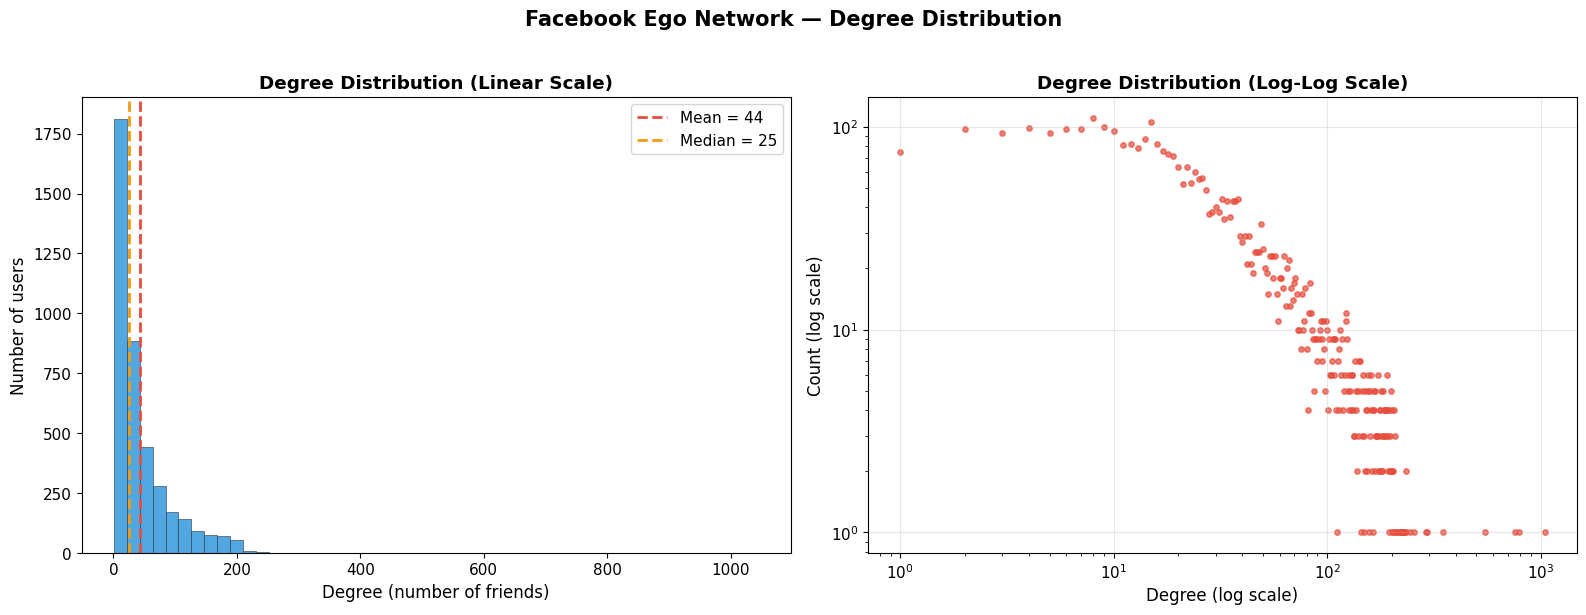

In [37]:
# Visualize degree distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Histogram (linear scale)
axes[0].hist(degree_values, bins=50, color='#3498DB', edgecolor='#2C3E50',
             linewidth=0.5, alpha=0.85)
axes[0].axvline(np.mean(degree_values), color='#E74C3C', linestyle='--',
                linewidth=2, label=f'Mean = {np.mean(degree_values):.0f}')
axes[0].axvline(np.median(degree_values), color='#F39C12', linestyle='--',
                linewidth=2, label=f'Median = {np.median(degree_values):.0f}')
axes[0].set_xlabel('Degree (number of friends)', fontsize=12)
axes[0].set_ylabel('Number of users', fontsize=12)
axes[0].set_title('Degree Distribution (Linear Scale)', fontweight='bold')
axes[0].legend(fontsize=11)

# Right: Log-log plot (to check for power law)
degree_count = Counter(degree_values)
deg_sorted = sorted(degree_count.keys())
count_sorted = [degree_count[d] for d in deg_sorted]

axes[1].scatter(deg_sorted, count_sorted, s=15, color='#E74C3C', alpha=0.7)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Degree (log scale)', fontsize=12)
axes[1].set_ylabel('Count (log scale)', fontsize=12)
axes[1].set_title('Degree Distribution (Log-Log Scale)', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Facebook Ego Network — Degree Distribution',
            fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 💬 Discussion: What do we see?

1. **Right-skewed distribution** — Most users have relatively few friends, but a small number of "hubs" have hundreds.
2. **Log-log plot** — The roughly linear pattern in the log-log plot hints at a **power-law** (scale-free) structure, which is common in social networks.
3. **Mean > Median** — The average (≈43) is much higher than the median (≈25), pulled up by the highly connected hubs. The "typical" user has about 25 friends, not 43.

## 1.3 Centrality Analysis — Who Are the Most "Important" Users?

In [38]:
# This may take a minute on the full graph
print("Computing centrality measures (this may take ~30 seconds)...")

degree_cent_fb = nx.degree_centrality(G_fb)
betweenness_cent_fb = nx.betweenness_centrality(G_fb, k=500, seed=42)  # approximate for speed
closeness_cent_fb = nx.closeness_centrality(G_fb)
eigenvector_cent_fb = nx.eigenvector_centrality(G_fb, max_iter=500)

print("✅ Done!\n")

# Build comparison table for top users
df_cent = pd.DataFrame({
    'Node': list(G_fb.nodes()),
    'Degree': [degrees_fb[n] for n in G_fb.nodes()],
    'Degree Cent.': [round(degree_cent_fb[n], 4) for n in G_fb.nodes()],
    'Betweenness Cent.': [round(betweenness_cent_fb[n], 4) for n in G_fb.nodes()],
    'Closeness Cent.': [round(closeness_cent_fb[n], 4) for n in G_fb.nodes()],
    'Eigenvector Cent.': [round(eigenvector_cent_fb[n], 4) for n in G_fb.nodes()],
})

print("Top 10 by BETWEENNESS Centrality (bridge nodes):")
print(df_cent.nlargest(10, 'Betweenness Cent.').to_string(index=False))

print("\nTop 10 by EIGENVECTOR Centrality (connected to important people):")
print(df_cent.nlargest(10, 'Eigenvector Cent.').to_string(index=False))

Computing centrality measures (this may take ~30 seconds)...
✅ Done!

Top 10 by BETWEENNESS Centrality (bridge nodes):
 Node  Degree  Degree Cent.  Betweenness Cent.  Closeness Cent.  Eigenvector Cent.
  107    1045        0.2588             0.4897           0.4597             0.0003
 1684     792        0.1961             0.3445           0.3936             0.0000
 3437     547        0.1355             0.2222           0.3144             0.0000
 1912     755        0.1870             0.2163           0.3509             0.0954
    0     347        0.0859             0.1614           0.3533             0.0000
 1085      66        0.0163             0.1503           0.3579             0.0000
  698      68        0.0168             0.1136           0.2712             0.0000
  567      63        0.0156             0.0882           0.3289             0.0000
   58      12        0.0030             0.0827           0.3974             0.0006
  428     115        0.0285             0.0608     

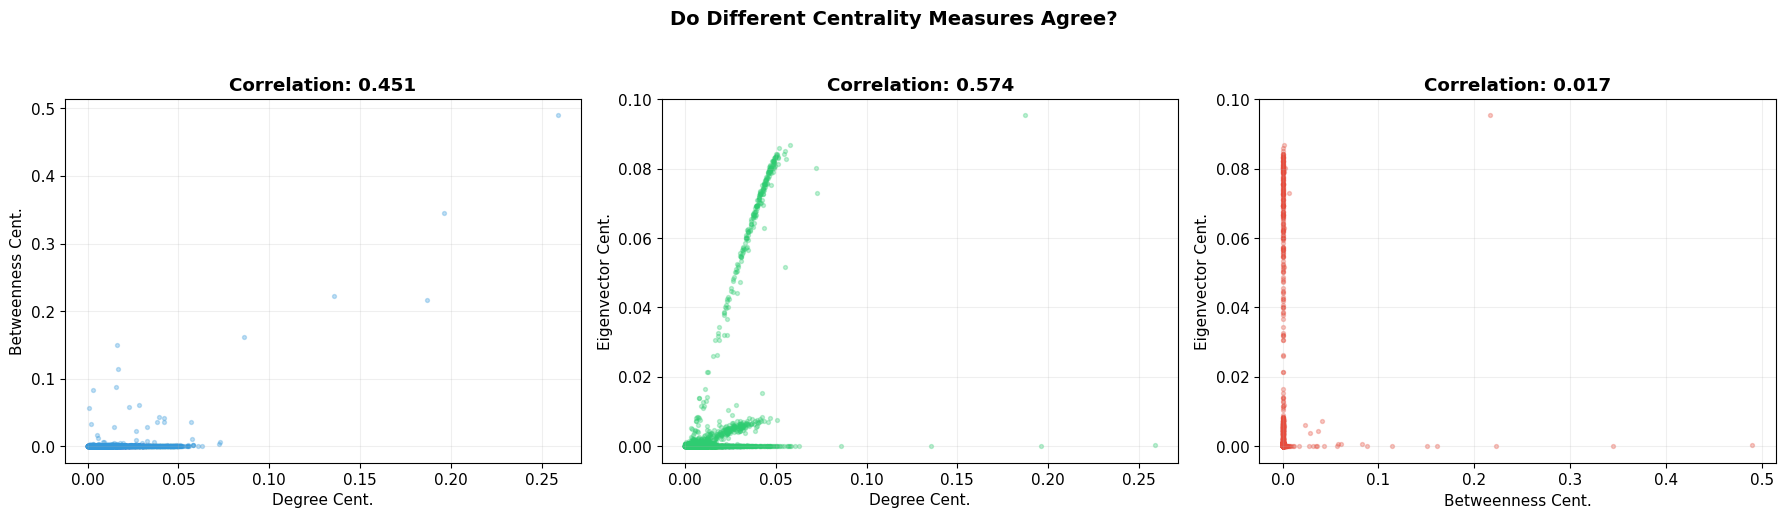

In [39]:
# Visualize: do the centrality measures agree?
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

comparisons = [
    ('Degree Cent.', 'Betweenness Cent.', '#3498DB'),
    ('Degree Cent.', 'Eigenvector Cent.', '#2ECC71'),
    ('Betweenness Cent.', 'Eigenvector Cent.', '#E74C3C'),
]

for ax, (x_col, y_col, color) in zip(axes, comparisons):
    ax.scatter(df_cent[x_col], df_cent[y_col], s=8, alpha=0.3, color=color)
    corr = df_cent[x_col].corr(df_cent[y_col])
    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel(y_col, fontsize=11)
    ax.set_title(f'Correlation: {corr:.3f}', fontweight='bold')
    ax.grid(True, alpha=0.2)

plt.suptitle('Do Different Centrality Measures Agree?',
            fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

### 💬 Discussion: Why don't all centralities agree?

- **Degree centrality** counts raw connections — a popularity measure.
- **Betweenness centrality** measures who sits on shortest paths between others — these are **bridge** people who connect different groups.
- **Eigenvector centrality** gives credit for being connected to other important people — not just how many, but **who** you're connected to.

A user can be highly connected (high degree) but only within a single clique (low betweenness). Conversely, someone with moderate connections but linking two large groups will have high betweenness.

## 1.4 Community Detection — Finding Social Circles

In [43]:
# Louvain community detection
import pandas as pd
from collections import Counter

# Correct Louvain import
try:
    import community.community_louvain as community_louvain
except ImportError:
    import community as community_louvain

print("Running Louvain community detection...")
partition_fb = community_louvain.best_partition(G_fb, random_state=42)

n_communities = len(set(partition_fb.values()))
modularity = community_louvain.modularity(partition_fb, G_fb)

print(f"✅ Found {n_communities} communities")
print(f"   Modularity score: {modularity:.4f}")
print(f"   (Modularity ranges from -0.5 to 1.0; higher = better separation)")

# Community size distribution
comm_sizes = Counter(partition_fb.values())
comm_df = pd.DataFrame([
    {'Community': k, 'Size': v} for k, v in comm_sizes.most_common()
])

print(f"\nCommunity Sizes (top 10):")
for _, row in comm_df.head(10).iterrows():
    bar = '█' * (row['Size'] // 15)
    print(f"   Community {row['Community']:>2}: {row['Size']:>4} users  {bar}")

Running Louvain community detection...
✅ Found 15 communities
   Modularity score: 0.8349
   (Modularity ranges from -0.5 to 1.0; higher = better separation)

Community Sizes (top 10):
   Community 10:  548 users  ████████████████████████████████████
   Community  2:  535 users  ███████████████████████████████████
   Community  4:  442 users  █████████████████████████████
   Community  9:  432 users  ████████████████████████████
   Community  1:  430 users  ████████████████████████████
   Community  0:  354 users  ███████████████████████
   Community  6:  323 users  █████████████████████
   Community 12:  237 users  ███████████████
   Community  8:  226 users  ███████████████
   Community  5:  206 users  █████████████


Computing layout (this may take ~20 seconds for 4,039 nodes)...


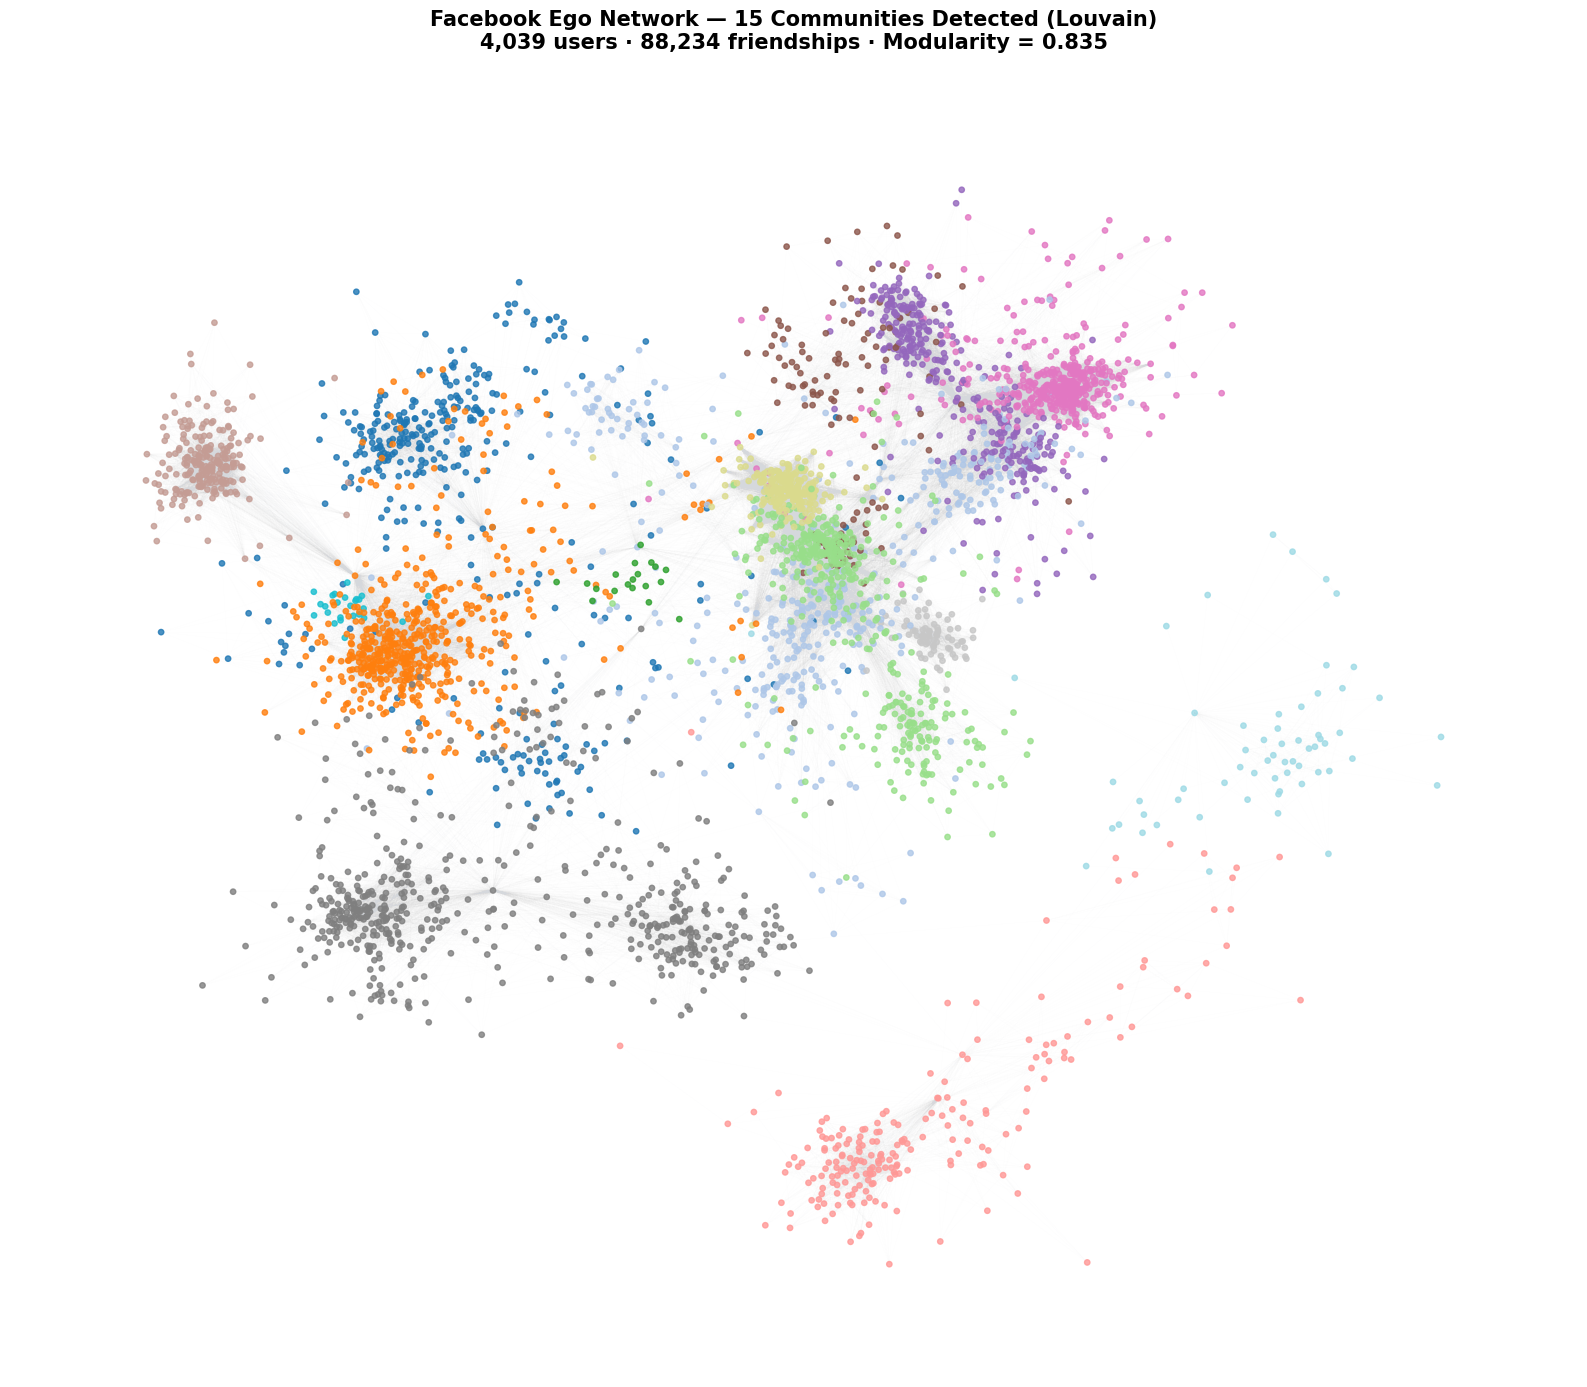


💡 Each color represents a detected community (social circle).
   Notice how the network naturally clusters into distinct groups!


In [45]:
# Visualize the full network colored by community
# Use a layout that respects community structure
print("Computing layout (this may take ~20 seconds for 4,039 nodes)...")

pos_fb = nx.spring_layout(G_fb, seed=42, k=0.05, iterations=50)

fig, ax = plt.subplots(figsize=(16, 14))

# Color map for communities
cmap = plt.cm.get_cmap('tab20', n_communities)
node_colors = [partition_fb[n] for n in G_fb.nodes()]

# Draw edges first (very light)
nx.draw_networkx_edges(G_fb, pos_fb, edge_color='#D5D8DC', width=0.1,
                       alpha=0.15, ax=ax)

# Draw nodes colored by community
nodes = nx.draw_networkx_nodes(G_fb, pos_fb, node_color=node_colors,
                                cmap=cmap, node_size=15, alpha=0.8, ax=ax)

ax.set_title(f'Facebook Ego Network — {n_communities} Communities Detected (Louvain)\n'
             f'4,039 users · 88,234 friendships · Modularity = {modularity:.3f}',
             fontsize=15, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()

print("\n💡 Each color represents a detected community (social circle).")
print("   Notice how the network naturally clusters into distinct groups!")

## 1.5 Small-World Analysis — Six Degrees of Separation?

In [46]:
# Small-world properties
print("Computing small-world properties...")

avg_path = nx.average_shortest_path_length(G_fb)
diameter = nx.diameter(G_fb)
avg_clustering = nx.average_clustering(G_fb)

# Compare with equivalent random graph (Erdos-Renyi)
n_fb = G_fb.number_of_nodes()
m_fb = G_fb.number_of_edges()
p_fb = 2 * m_fb / (n_fb * (n_fb - 1))  # edge probability

# Expected clustering for random graph: C_random ≈ p
# Expected path length for random graph: L_random ≈ ln(n) / ln(k)
avg_degree = 2 * m_fb / n_fb
expected_clustering_random = p_fb
expected_path_random = np.log(n_fb) / np.log(avg_degree)

print(f"\n{'='*60}")
print(f"  SMALL-WORLD ANALYSIS")
print(f"{'='*60}")
print(f"  {'Metric':<35} {'Facebook':>12} {'Random (expected)':>18}")
print(f"  {'-'*65}")
print(f"  {'Avg. clustering coefficient':<35} {avg_clustering:>12.4f} {expected_clustering_random:>18.4f}")
print(f"  {'Avg. shortest path length':<35} {avg_path:>12.4f} {expected_path_random:>18.4f}")
print(f"  {'Diameter (longest shortest path)':<35} {diameter:>12}")
print(f"  {'Avg. degree':<35} {avg_degree:>12.1f}")
print(f"{'='*60}")

# Small-world coefficient
sigma_clustering = avg_clustering / expected_clustering_random
sigma_path = avg_path / expected_path_random

print(f"\n  Small-world indicators:")
print(f"    Clustering ratio (C_real / C_random): {sigma_clustering:.1f}x")
print(f"    Path length ratio (L_real / L_random): {sigma_path:.2f}x")
print(f"\n  ✅ Small-world? Clustering is {sigma_clustering:.0f}x higher than random,")
print(f"     but path lengths are only {sigma_path:.1f}x longer.")
print(f"     → YES, this is a small-world network!")

Computing small-world properties...

  SMALL-WORLD ANALYSIS
  Metric                                  Facebook  Random (expected)
  -----------------------------------------------------------------
  Avg. clustering coefficient               0.6055             0.0108
  Avg. shortest path length                 3.6925             2.1984
  Diameter (longest shortest path)               8
  Avg. degree                                 43.7

  Small-world indicators:
    Clustering ratio (C_real / C_random): 56.0x
    Path length ratio (L_real / L_random): 1.68x

  ✅ Small-world? Clustering is 56x higher than random,
     but path lengths are only 1.7x longer.
     → YES, this is a small-world network!


Sampling shortest path lengths (this may take a moment)...


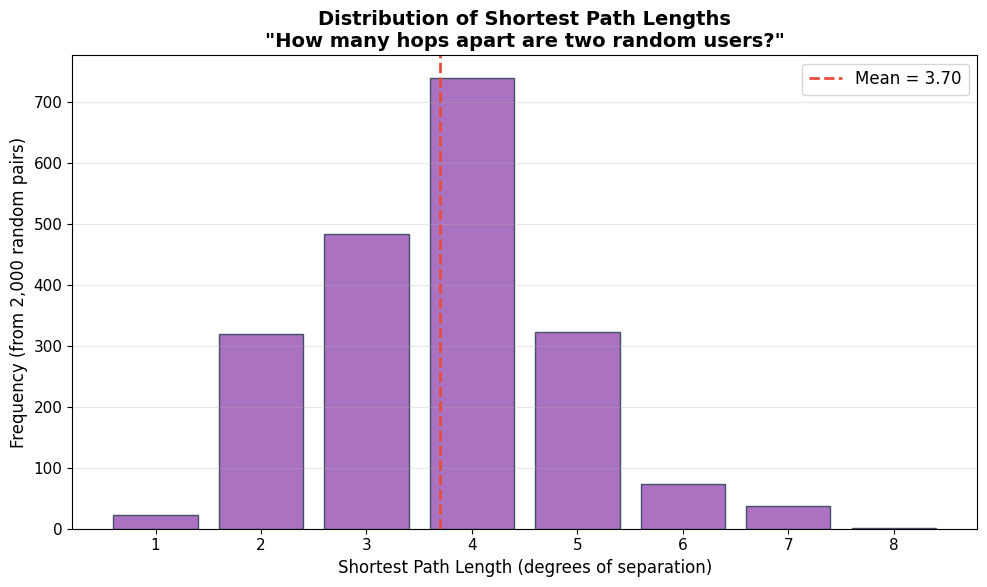


💡 Most pairs of users are only 4-4 hops apart!
   This is the 'small-world' phenomenon in action.


In [47]:
# Distribution of shortest path lengths
print("Sampling shortest path lengths (this may take a moment)...")

# Sample 1000 random pairs for efficiency
np.random.seed(42)
all_nodes = list(G_fb.nodes())
sampled_paths = []
for _ in range(2000):
    s, t = np.random.choice(all_nodes, size=2, replace=False)
    try:
        length = nx.shortest_path_length(G_fb, source=s, target=t)
        sampled_paths.append(length)
    except nx.NetworkXNoPath:
        pass

fig, ax = plt.subplots(figsize=(10, 6))
path_counts = Counter(sampled_paths)
x = sorted(path_counts.keys())
y = [path_counts[k] for k in x]

ax.bar(x, y, color='#9B59B6', edgecolor='#2C3E50', linewidth=1, alpha=0.85)
ax.axvline(np.mean(sampled_paths), color='#E74C3C', linestyle='--', linewidth=2,
           label=f'Mean = {np.mean(sampled_paths):.2f}')
ax.set_xlabel('Shortest Path Length (degrees of separation)', fontsize=12)
ax.set_ylabel('Frequency (from 2,000 random pairs)', fontsize=12)
ax.set_title('Distribution of Shortest Path Lengths\n'
             '"How many hops apart are two random users?"',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n💡 Most pairs of users are only {int(np.median(sampled_paths))}-{int(np.mean(sampled_paths)+0.5)} hops apart!")
print(f"   This is the 'small-world' phenomenon in action.")

## 1.6 Network Visualization — Zooming Into a Community

Largest community (Community 10):
  Nodes: 548
  Edges: 5356
  Density: 0.0357
  Avg. Clustering: 0.6246


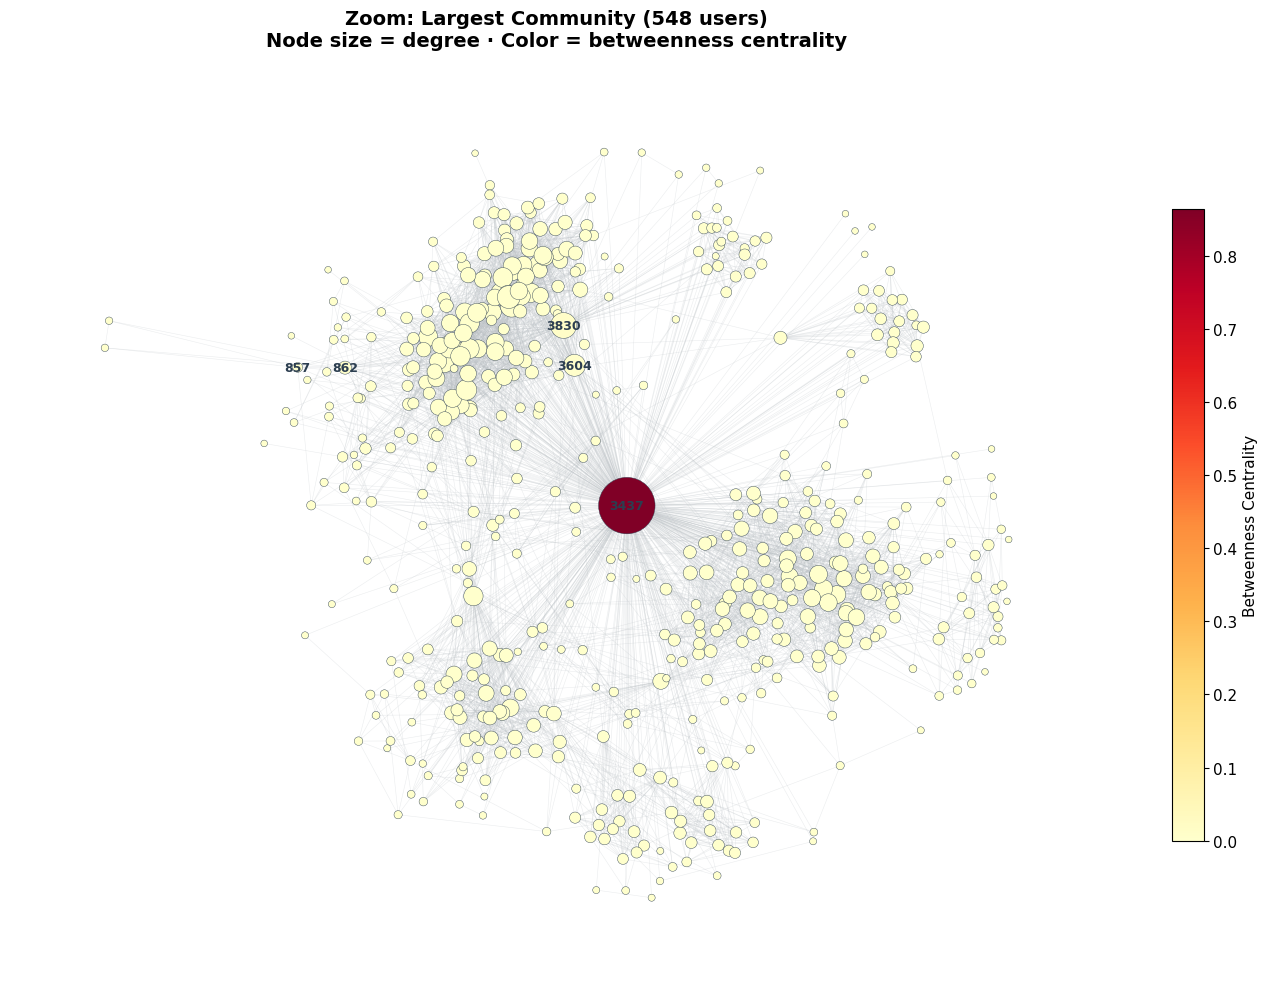

In [48]:
# Pick the largest community and visualize it in detail
largest_comm_id = comm_df.iloc[0]['Community']
largest_comm_nodes = [n for n, c in partition_fb.items() if c == largest_comm_id]

G_comm = G_fb.subgraph(largest_comm_nodes).copy()

print(f"Largest community (Community {largest_comm_id}):")
print(f"  Nodes: {G_comm.number_of_nodes()}")
print(f"  Edges: {G_comm.number_of_edges()}")
print(f"  Density: {nx.density(G_comm):.4f}")
print(f"  Avg. Clustering: {nx.average_clustering(G_comm):.4f}")

# Visualize the subgraph with betweenness centrality coloring
fig, ax = plt.subplots(figsize=(14, 10))

pos_comm = nx.spring_layout(G_comm, seed=42, k=0.15)
bc_comm = nx.betweenness_centrality(G_comm)
bc_vals = [bc_comm[n] for n in G_comm.nodes()]
deg_comm = dict(G_comm.degree())
node_sizes = [deg_comm[n] * 3 + 20 for n in G_comm.nodes()]

nx.draw_networkx_edges(G_comm, pos_comm, edge_color='#BDC3C7', width=0.4,
                       alpha=0.3, ax=ax)
nodes = nx.draw_networkx_nodes(G_comm, pos_comm, node_color=bc_vals,
                                cmap=plt.cm.YlOrRd, node_size=node_sizes,
                                edgecolors='#2C3E50', linewidths=0.3, ax=ax)

# Label the top 5 most central nodes
top5_comm = sorted(bc_comm.items(), key=lambda x: -x[1])[:5]
labels_comm = {n: str(n) for n, _ in top5_comm}
nx.draw_networkx_labels(G_comm, pos_comm, labels=labels_comm,
                        font_size=9, font_weight='bold', font_color='#2C3E50', ax=ax)

plt.colorbar(nodes, ax=ax, label='Betweenness Centrality', shrink=0.7)
ax.set_title(f'Zoom: Largest Community ({G_comm.number_of_nodes()} users)\n'
             f'Node size = degree · Color = betweenness centrality',
             fontsize=14, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()

## 1.7 Key Findings Summary

In [49]:
# Final comprehensive summary
print("\n" + "═"*60)
print("  📊 FACEBOOK EGO NETWORK — KEY FINDINGS")
print("═"*60)
print(f"""
  1. SCALE
     • 4,039 users with 88,234 friendships
     • Average of {avg_degree:.0f} friends per person

  2. DEGREE DISTRIBUTION
     • Heavy-tailed / power-law-like distribution
     • Most users have ~25 friends (median)
     • A few 'hubs' have 300+ friends

  3. SMALL-WORLD PROPERTY ✅
     • High clustering ({avg_clustering:.3f}) — {sigma_clustering:.0f}x higher than random
     • Short paths (avg {avg_path:.2f} hops, diameter {diameter})
     • "Everyone knows everyone through ~3-4 people"

  4. COMMUNITY STRUCTURE
     • {n_communities} communities detected (Louvain)
     • Modularity = {modularity:.3f} (strong community structure)
     • Communities likely represent real social circles

  5. CENTRALITY
     • Different centrality measures highlight different roles
     • High betweenness nodes = bridges between communities
     • High eigenvector nodes = connected to other influencers
""")
print("═"*60)


════════════════════════════════════════════════════════════
  📊 FACEBOOK EGO NETWORK — KEY FINDINGS
════════════════════════════════════════════════════════════

  1. SCALE
     • 4,039 users with 88,234 friendships
     • Average of 44 friends per person

  2. DEGREE DISTRIBUTION
     • Heavy-tailed / power-law-like distribution
     • Most users have ~25 friends (median)
     • A few 'hubs' have 300+ friends

  3. SMALL-WORLD PROPERTY ✅
     • High clustering (0.606) — 56x higher than random
     • Short paths (avg 3.69 hops, diameter 8)
     • "Everyone knows everyone through ~3-4 people"

  4. COMMUNITY STRUCTURE
     • 15 communities detected (Louvain)
     • Modularity = 0.835 (strong community structure)
     • Communities likely represent real social circles

  5. CENTRALITY
     • Different centrality measures highlight different roles
     • High betweenness nodes = bridges between communities
     • High eigenvector nodes = connected to other influencers

═════════════════

---
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# PART 2: Email-Eu-Core Network (Guided Student Exercise)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 📖 About the Dataset

This dataset comes from SNAP Stanford and represents **email communication** at a large **European research institution**:

- **Nodes** = 1,005 members of the institution
- **Edges** = An edge (u, v) means person u sent at least one email to person v
- **Ground-truth labels** = Each person belongs to exactly one of **42 departments**

This is a **directed** network (sending an email is one-directional), and we also have the true department memberships, which lets us evaluate whether our community detection can recover real organizational structure.

**Your mission:** Analyze this network step by step, following the guided exercises below. Each exercise builds on the previous one.

---

## 2.1 Load the Data

Run the cell below to download and load the Email-Eu-Core dataset.

In [7]:
# Download email-Eu-core dataset
import os
import urllib.request
import gzip
import networkx as nx # Added this import

url_email_edges = "https://snap.stanford.edu/data/email-Eu-core.txt.gz"
url_email_labels = "https://snap.stanford.edu/data/email-Eu-core-department-labels.txt.gz"

# Download edges
if not os.path.exists("email-Eu-core.txt"):
    print("Downloading Email-Eu-Core edges...")
    urllib.request.urlretrieve(url_email_edges, "email-Eu-core.txt.gz")
    with gzip.open("email-Eu-core.txt.gz", 'rb') as f_in:
        with open("email-Eu-core.txt", 'wb') as f_out:
            f_out.write(f_in.read())

# Download department labels
if not os.path.exists("email-Eu-core-department-labels.txt"):
    print("Downloading department labels...")
    urllib.request.urlretrieve(url_email_labels, "email-Eu-core-department-labels.txt.gz")
    with gzip.open("email-Eu-core-department-labels.txt.gz", 'rb') as f_in:
        with open("email-Eu-core-department-labels.txt", 'wb') as f_out:
            f_out.write(f_in.read())

print("✅ Download complete!")

# Load the DIRECTED graph
G_email_directed = nx.read_edgelist("email-Eu-core.txt", nodetype=int,
                                     create_using=nx.DiGraph())

# Also create an UNDIRECTED version (useful for some analyses)
G_email = G_email_directed.to_undirected()

# Load department labels
dept_labels = {}
with open("email-Eu-core-department-labels.txt", 'r') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) == 2:
            node_id, dept_id = int(parts[0]), int(parts[1])
            dept_labels[node_id] = dept_id

print(f"\n{'='*55}")
print(f"  EMAIL-EU-CORE NETWORK — Loaded!")
print(f"{'='*55}")
print(f"  Directed graph:")
print(f"    Nodes: {G_email_directed.number_of_nodes():,}")
print(f"    Edges: {G_email_directed.number_of_edges():,}")
print(f"  Undirected version:")
print(f"    Nodes: {G_email.number_of_nodes():,}")
print(f"    Edges: {G_email.number_of_edges():,}")
print(f"  Departments: {len(set(dept_labels.values()))}")
print(f"  Labeled nodes: {len(dept_labels)}")
print(f"{'='*55}")

✅ Download complete!

  EMAIL-EU-CORE NETWORK — Loaded!
  Directed graph:
    Nodes: 1,005
    Edges: 25,571
  Undirected version:
    Nodes: 1,005
    Edges: 16,706
  Departments: 42
  Labeled nodes: 1005


---
## ✏️ Exercise 1: Basic Exploration (Easy)

Let's get to know our dataset. Complete the tasks below.

**Tasks:**
1. Calculate the **density** of the undirected email network
2. Check if the undirected network is **connected** (all nodes reachable from any other)
3. Find the **largest connected component** and report how many nodes it contains
4. What percentage of the network is in the largest connected component?

**Hints** are provided in the comments.

In [9]:
# ============================================
# EXERCISE 1: Basic Exploration
# ============================================

# Task 1: Calculate density
# Hint: nx.density(G_email)
density_email = nx.density(G_email)  # YOUR CODE HERE
print(f"Network density: {density_email:.5f}")

# Task 2: Check connectivity
# Hint: nx.is_connected(G_email)
is_connected = nx.is_connected(G_email)  # YOUR CODE HERE
print(f"Is connected: {is_connected}")

# Task 3: Find the largest connected component
# Hint: max(nx.connected_components(G_email), key=len)
largest_cc = max(nx.connected_components(G_email), key=len)  # YOUR CODE HERE
print(f"Largest connected component: {len(largest_cc)} nodes")

# Task 4: Percentage of network in largest component
pct = len(largest_cc) / G_email.number_of_nodes() * 100  # YOUR CODE HERE
print(f"Percentage: {pct:.1f}%")

Network density: 0.03311
Is connected: False
Largest connected component: 986 nodes
Percentage: 98.1%


In [ ]:
# ══════════════════════════════════════════
# SOLUTION — Exercise 1 (run after trying!)
# ══════════════════════════════════════════

density_email = nx.density(G_email)
print(f"Network density: {density_email:.5f}")
print(f"  → About {density_email*100:.1f}% of all possible emails actually happened.\n")

is_connected = nx.is_connected(G_email)
print(f"Is connected: {is_connected}")

if not is_connected:
    components = list(nx.connected_components(G_email))
    print(f"  Number of components: {len(components)}")
    largest_cc = max(components, key=len)
else:
    largest_cc = set(G_email.nodes())

print(f"\nLargest connected component: {len(largest_cc)} nodes")
pct = len(largest_cc) / G_email.number_of_nodes() * 100
print(f"Percentage of network: {pct:.1f}%")

---
## ✏️ Exercise 2: Degree Analysis (Easy–Medium)

Since this is an email network with a directed version, we can look at **in-degree** (emails received) and **out-degree** (emails sent).

**Tasks:**
1. Calculate in-degree and out-degree for all nodes in the **directed** graph
2. Who are the **top 5 email senders** (highest out-degree)?
3. Who are the **top 5 email receivers** (highest in-degree)?
4. Create a **scatter plot** of in-degree vs out-degree. What pattern do you see?
5. Which department do the top senders belong to? (use `dept_labels` dictionary)

Top 5 Email Senders (out-degree):
  #1 Node 160   → 334 emails sent   (Dept 36)
  #2 Node 82    → 227 emails sent   (Dept 36)
  #3 Node 121   → 222 emails sent   (Dept 36)
  #4 Node 107   → 204 emails sent   (Dept 36)
  #5 Node 86    → 202 emails sent   (Dept 36)

Top 5 Email Receivers (in-degree):
  #1 Node 160   → 212 emails received (Dept 36)
  #2 Node 62    → 179 emails received (Dept 36)
  #3 Node 107   → 169 emails received (Dept 36)
  #4 Node 121   → 157 emails received (Dept 36)
  #5 Node 86    → 154 emails received (Dept 36)


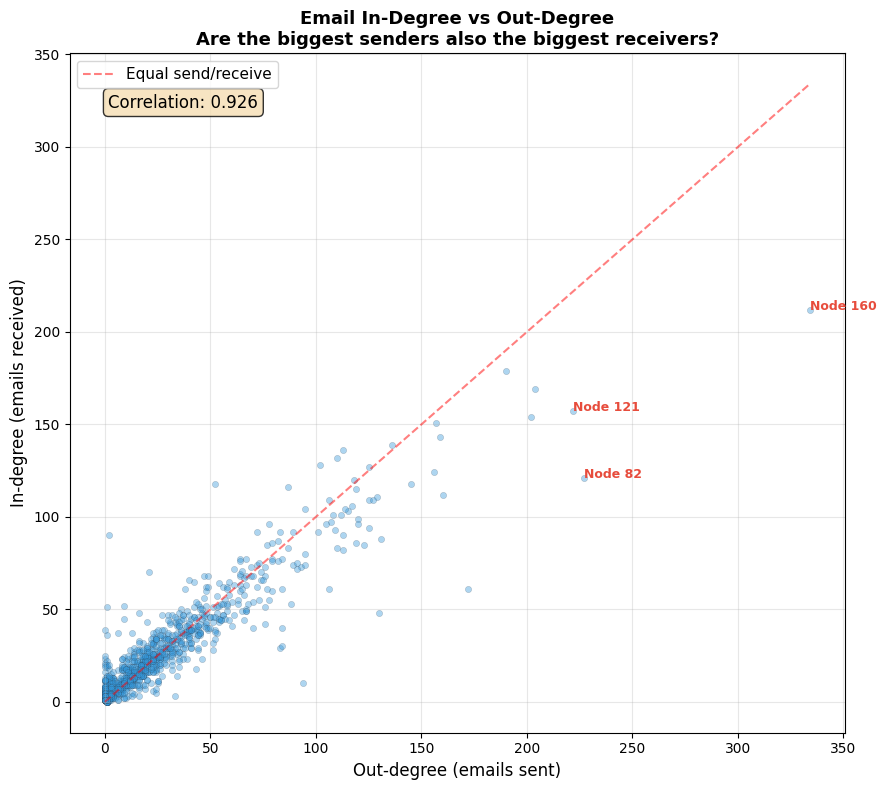


💡 Correlation between in-degree and out-degree: 0.926
   People who send a lot of emails tend to also receive a lot!


In [12]:
# ============================================
# EXERCISE 2: Degree Analysis
# ============================================

import matplotlib.pyplot as plt
import numpy as np # Added this import for np.corrcoef

# Task 1: Calculate in-degree and out-degree
# Hint: G_email_directed.in_degree() and G_email_directed.out_degree()
in_degrees = dict(G_email_directed.in_degree())
out_degrees = dict(G_email_directed.out_degree())

# Task 2: Top 5 senders (highest out-degree)
# Hint: sorted(out_degrees.items(), key=lambda x: -x[1])[:5]
top_senders = sorted(out_degrees.items(), key=lambda x: -x[1])[:5]
print("Top 5 Email Senders (out-degree):")
for rank, (node, deg) in enumerate(top_senders, 1):
    dept = dept_labels.get(node, '?')
    print(f"  #{rank} Node {node:<5} → {deg:>3} emails sent   (Dept {dept})")

# Task 3: Top 5 receivers (highest in-degree)
top_receivers = sorted(in_degrees.items(), key=lambda x: -x[1])[:5]
print("\nTop 5 Email Receivers (in-degree):")
for rank, (node, deg) in enumerate(top_receivers, 1):
    dept = dept_labels.get(node, '?')
    print(f"  #{rank} Node {node:<5} → {deg:>3} emails received (Dept {dept})")


# Task 4: Scatter plot of in-degree vs out-degree
# Hint:
# fig, ax = plt.subplots(figsize=(8, 8))
# x = [out_degrees[n] for n in G_email_directed.nodes()]
# y = [in_degrees[n] for n in G_email_directed.nodes()]
# ax.scatter(x, y, ...)

fig, ax = plt.subplots(figsize=(9, 8))
x = [out_degrees.get(n, 0) for n in G_email_directed.nodes()]
y = [in_degrees.get(n, 0) for n in G_email_directed.nodes()]

ax.scatter(x, y, s=20, alpha=0.4, color='#3498DB', edgecolors='#2C3E50', linewidths=0.3)

# Add diagonal reference line
max_val = max(max(x), max(y))
ax.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='Equal send/receive')

# Annotate top senders
for node, deg in top_senders[:3]:
    ax.annotate(f'Node {node}', (out_degrees[node], in_degrees[node]),
                fontsize=9, fontweight='bold', color='#E74C3C')

ax.set_xlabel('Out-degree (emails sent)', fontsize=12)
ax.set_ylabel('In-degree (emails received)', fontsize=12)
ax.set_title('Email In-Degree vs Out-Degree\n'+
             'Are the biggest senders also the biggest receivers?',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

corr = np.corrcoef(x, y)[0, 1]
ax.text(0.05, 0.92, f'Correlation: {corr:.3f}', transform=ax.transAxes,
        fontsize=12, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
plt.tight_layout()
plt.show()

print(f"\n💡 Correlation between in-degree and out-degree: {corr:.3f}")
print("   People who send a lot of emails tend to also receive a lot!")


# Task 5: Department of top senders
# This is already handled in the print statements for top senders/receivers above.

In [ ]:
# ══════════════════════════════════════════
# SOLUTION — Exercise 2
# ══════════════════════════════════════════

in_degrees = dict(G_email_directed.in_degree())
out_degrees = dict(G_email_directed.out_degree())

# Top 5 senders
top_senders = sorted(out_degrees.items(), key=lambda x: -x[1])[:5]
print("Top 5 Email Senders (out-degree):")
for rank, (node, deg) in enumerate(top_senders, 1):
    dept = dept_labels.get(node, '?')
    print(f"  #{rank} Node {node:<5} → {deg:>3} emails sent   (Dept {dept})")

# Top 5 receivers
top_receivers = sorted(in_degrees.items(), key=lambda x: -x[1])[:5]
print("\nTop 5 Email Receivers (in-degree):")
for rank, (node, deg) in enumerate(top_receivers, 1):
    dept = dept_labels.get(node, '?')
    print(f"  #{rank} Node {node:<5} → {deg:>3} emails received (Dept {dept})")

# Scatter plot
fig, ax = plt.subplots(figsize=(9, 8))
x = [out_degrees.get(n, 0) for n in G_email_directed.nodes()]
y = [in_degrees.get(n, 0) for n in G_email_directed.nodes()]

ax.scatter(x, y, s=20, alpha=0.4, color='#3498DB', edgecolors='#2C3E50', linewidths=0.3)

# Add diagonal reference line
max_val = max(max(x), max(y))
ax.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='Equal send/receive')

# Annotate top senders
for node, deg in top_senders[:3]:
    ax.annotate(f'Node {node}', (out_degrees[node], in_degrees[node]),
                fontsize=9, fontweight='bold', color='#E74C3C')

ax.set_xlabel('Out-degree (emails sent)', fontsize=12)
ax.set_ylabel('In-degree (emails received)', fontsize=12)
ax.set_title('Email In-Degree vs Out-Degree\n'
             'Are the biggest senders also the biggest receivers?',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

corr = np.corrcoef(x, y)[0, 1]
ax.text(0.05, 0.92, f'Correlation: {corr:.3f}', transform=ax.transAxes,
        fontsize=12, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
plt.tight_layout()
plt.show()

print(f"\n💡 Correlation between in-degree and out-degree: {corr:.3f}")
print("   People who send a lot of emails tend to also receive a lot!")

---
## ✏️ Exercise 3: Department-Level Analysis (Medium)

We have ground-truth department labels! Let's analyze communication patterns across departments.

**Tasks:**
1. How many members are in each department? Plot a bar chart of the **10 largest departments**.
2. For each of the **3 largest departments**, extract the subgraph and compute: density, average clustering, and average degree.
3. Create a **heatmap** showing how many emails flow between the top 10 departments.
4. Which department is the most "internally communicative" (highest within-department density)?

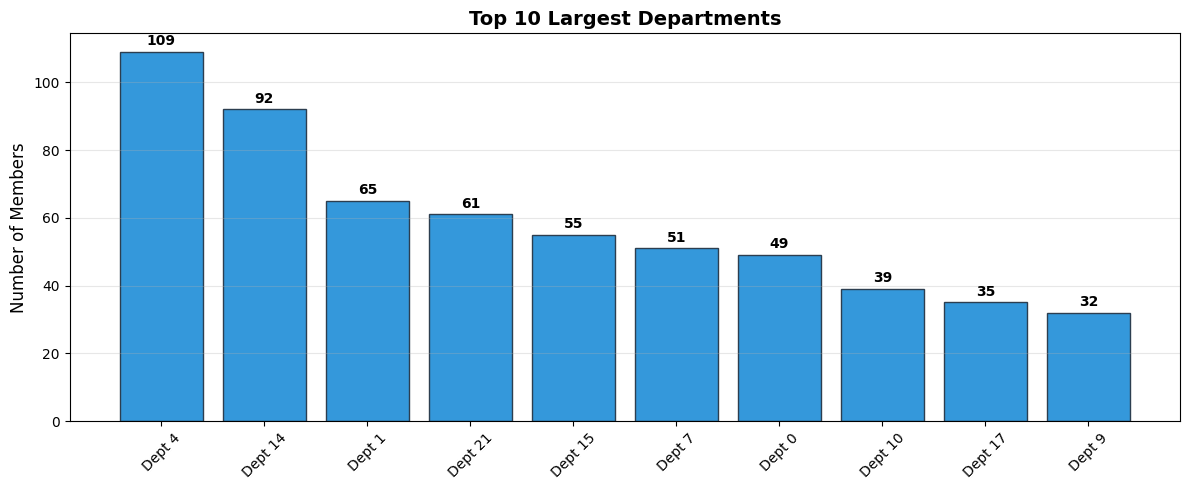


Dept       Size    Density   Avg Clust.   Avg Degree
--------------------------------------------------
  4         109     0.1381       0.4360         14.9
  14         92     0.2458       0.5031         22.4
  1          65     0.1769       0.5520         11.3


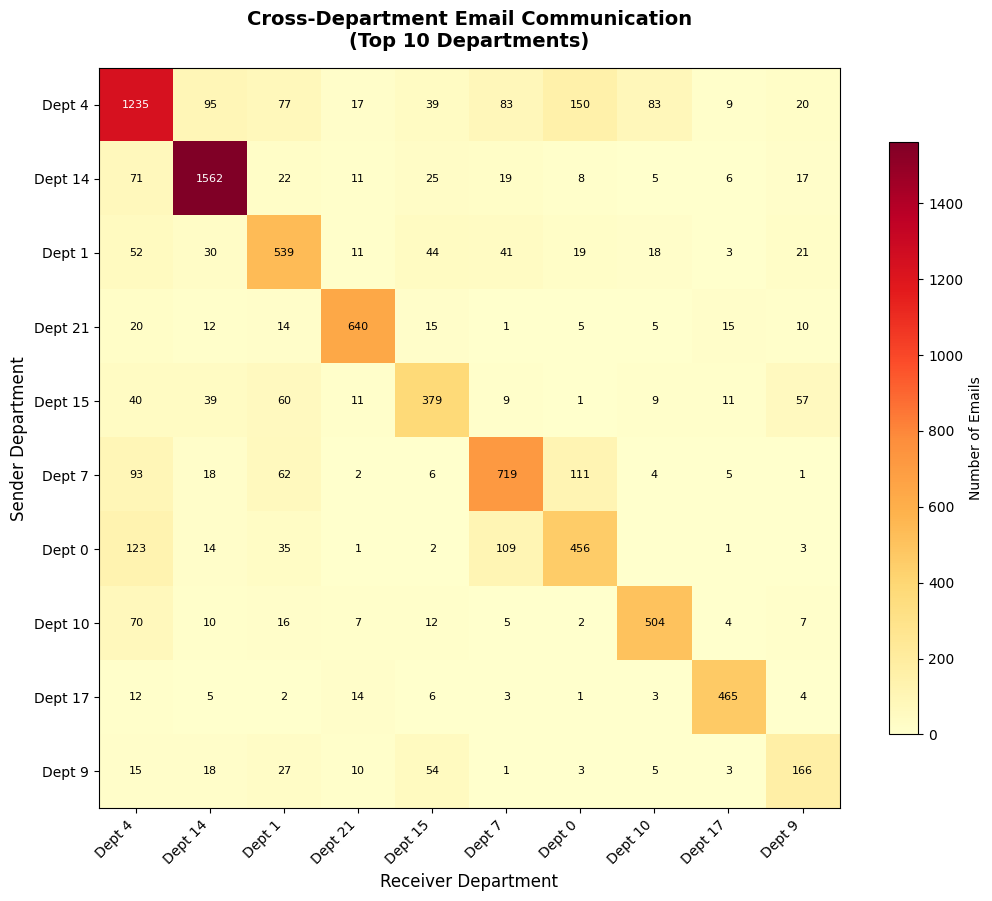


💡 Notice: The diagonal is much brighter than off-diagonal cells!
   This means most communication happens WITHIN departments.

Dept       Size   Internal Density
-----------------------------------
  4         109             0.1381
  14         92             0.2458
  1          65             0.1769
  21         61             0.2153
  15         55             0.1764
  7          51             0.3710
  0          49             0.2483
  10         39             0.4372
  17         35             0.4689
  9          32             0.2157
  11         29             0.5591
  19         29             0.5099
  6          28             0.0873
  23         27             0.1054
  13         26             0.5631
  22         25             0.2833
  16         25             0.5467
  36         22             0.6017
  8          19             0.5789
  5          18             0.6732
  37         15             0.6476
  20         14             0.5385
  34         13             0.4

In [13]:
# ============================================
# EXERCISE 3: Department-Level Analysis
# ============================================

# Task 1: Count department members and plot top 10
# Hint: Counter(dept_labels.values())
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd
import networkx as nx

dept_counts = Counter(dept_labels.values())
top_depts = dept_counts.most_common(10)

fig, ax = plt.subplots(figsize=(12, 5))
dept_ids = [f"Dept {d}" for d, _ in top_depts]
dept_sizes = [c for _, c in top_depts]
bars = ax.bar(dept_ids, dept_sizes, color='#3498DB', edgecolor='#2C3E50', linewidth=1)

for bar, size in zip(bars, dept_sizes):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
            str(size), ha='center', fontweight='bold', fontsize=10)

ax.set_ylabel('Number of Members', fontsize=12)
ax.set_title('Top 10 Largest Departments', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Task 2: Subgraph analysis for top 3 departments
# Hint:
# dept_nodes = [n for n, d in dept_labels.items() if d == dept_id]
# G_dept = G_email.subgraph(dept_nodes)
# nx.density(G_dept), nx.average_clustering(G_dept)

print(f"\n{'Dept':<8} {'Size':>6} {'Density':>10} {'Avg Clust.':>12} {'Avg Degree':>12}")
print("-" * 50)

top3_depts = [d for d, _ in dept_counts.most_common(3)]
for dept_id in top3_depts:
    dept_nodes = [n for n, d in dept_labels.items() if d == dept_id and n in G_email] # Ensure node is in G_email
    G_dept = G_email.subgraph(dept_nodes)
    if G_dept.number_of_nodes() > 1:
        deg_avg = 2 * G_dept.number_of_edges() / G_dept.number_of_nodes()
        print(f"  {dept_id:<6} {G_dept.number_of_nodes():>6} "
              f"{nx.density(G_dept):>10.4f} "
              f"{nx.average_clustering(G_dept):>12.4f} "
              f"{deg_avg:>12.1f}")
    else:
        print(f"  {dept_id:<6} {G_dept.number_of_nodes():>6} {'N/A':>10} {'N/A':>12} {'N/A':>12}")


# Task 3: Inter-department email heatmap
# Hint:
# Create a matrix where cell (i, j) = number of emails from dept i to dept j
# Loop through directed edges: for u, v in G_email_directed.edges():
#     dept_u = dept_labels.get(u), dept_v = dept_labels.get(v)

top10_dept_ids = [d for d, _ in dept_counts.most_common(10)]

# Build cross-department email count matrix
cross_dept = pd.DataFrame(0, index=top10_dept_ids, columns=top10_dept_ids)

for u, v in G_email_directed.edges():
    dept_u = dept_labels.get(u)
    dept_v = dept_labels.get(v)
    if dept_u in top10_dept_ids and dept_v in top10_dept_ids:
        cross_dept.loc[dept_u, dept_v] += 1

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(cross_dept.values, cmap='YlOrRd', aspect='equal')

# Labels
ax.set_xticks(range(len(top10_dept_ids)))
ax.set_yticks(range(len(top10_dept_ids)))
ax.set_xticklabels([f'Dept {d}' for d in top10_dept_ids], rotation=45, ha='right')
ax.set_yticklabels([f'Dept {d}' for d in top10_dept_ids])
ax.set_xlabel('Receiver Department', fontsize=12)
ax.set_ylabel('Sender Department', fontsize=12)

# Add values to cells
for i in range(len(top10_dept_ids)):
    for j in range(len(top10_dept_ids)):
        val = cross_dept.iloc[i, j]
        if val > 0: # Only display values greater than 0
            color = 'white' if val > cross_dept.values.max() * 0.5 else 'black'
            ax.text(j, i, str(val), ha='center', va='center', fontsize=8, color=color)

plt.colorbar(im, ax=ax, label='Number of Emails', shrink=0.8)
ax.set_title('Cross-Department Email Communication\n'
             '(Top 10 Departments)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\n💡 Notice: The diagonal is much brighter than off-diagonal cells!")
print("   This means most communication happens WITHIN departments.")

# Task 4: Most internally communicative department

print(f"\n{'Dept':<8} {'Size':>6} {'Internal Density':>18}")
print("-" * 35)

dept_densities = {}
for dept_id, count in dept_counts.most_common(): # Iterate through all departments
    dept_nodes = [n for n, d in dept_labels.items() if d == dept_id and n in G_email]
    if len(dept_nodes) > 1: # Need at least 2 nodes to calculate density
        G_dept = G_email.subgraph(dept_nodes)
        d = nx.density(G_dept)
        dept_densities[dept_id] = d
        print(f"  {dept_id:<6} {len(dept_nodes):>6} {d:>18.4f}")

best_dept = max(dept_densities, key=dept_densities.get)
print(f"\n🏆 Most internally communicative: Department {best_dept} "
      f"(density = {dept_densities[best_dept]:.4f})")

In [ ]:
# ══════════════════════════════════════════
# SOLUTION — Exercise 3
# ══════════════════════════════════════════

# Task 1: Department sizes
dept_counts = Counter(dept_labels.values())
top_depts = dept_counts.most_common(10)

fig, ax = plt.subplots(figsize=(12, 5))
dept_ids = [f"Dept {d}" for d, _ in top_depts]
dept_sizes = [c for _, c in top_depts]
bars = ax.bar(dept_ids, dept_sizes, color='#3498DB', edgecolor='#2C3E50', linewidth=1)

for bar, size in zip(bars, dept_sizes):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
            str(size), ha='center', fontweight='bold', fontsize=10)

ax.set_ylabel('Number of Members', fontsize=12)
ax.set_title('Top 10 Largest Departments', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Task 2: Subgraph analysis for top 3 departments
print(f"\n{'Dept':<8} {'Size':>6} {'Density':>10} {'Avg Clust.':>12} {'Avg Degree':>12}")
print("-" * 50)

top3_depts = [d for d, _ in dept_counts.most_common(3)]
for dept_id in top3_depts:
    dept_nodes = [n for n, d in dept_labels.items() if d == dept_id and n in G_email]
    G_dept = G_email.subgraph(dept_nodes)
    if G_dept.number_of_nodes() > 1:
        deg_avg = 2 * G_dept.number_of_edges() / G_dept.number_of_nodes()
        print(f"  {dept_id:<6} {G_dept.number_of_nodes():>6} "
              f"{nx.density(G_dept):>10.4f} "
              f"{nx.average_clustering(G_dept):>12.4f} "
              f"{deg_avg:>12.1f}")

In [ ]:
# Task 3: Inter-department email heatmap
top10_dept_ids = [d for d, _ in dept_counts.most_common(10)]

# Build cross-department email count matrix
cross_dept = pd.DataFrame(0, index=top10_dept_ids, columns=top10_dept_ids)

for u, v in G_email_directed.edges():
    dept_u = dept_labels.get(u)
    dept_v = dept_labels.get(v)
    if dept_u in top10_dept_ids and dept_v in top10_dept_ids:
        cross_dept.loc[dept_u, dept_v] += 1

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(cross_dept.values, cmap='YlOrRd', aspect='equal')

# Labels
ax.set_xticks(range(len(top10_dept_ids)))
ax.set_yticks(range(len(top10_dept_ids)))
ax.set_xticklabels([f'Dept {d}' for d in top10_dept_ids], rotation=45, ha='right')
ax.set_yticklabels([f'Dept {d}' for d in top10_dept_ids])
ax.set_xlabel('Receiver Department', fontsize=12)
ax.set_ylabel('Sender Department', fontsize=12)

# Add values to cells
for i in range(len(top10_dept_ids)):
    for j in range(len(top10_dept_ids)):
        val = cross_dept.iloc[i, j]
        color = 'white' if val > cross_dept.values.max() * 0.5 else 'black'
        ax.text(j, i, str(val), ha='center', va='center', fontsize=8, color=color)

plt.colorbar(im, ax=ax, label='Number of Emails', shrink=0.8)
ax.set_title('Cross-Department Email Communication\n'
             '(Top 10 Departments)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\n💡 Notice: The diagonal is much brighter than off-diagonal cells!")
print("   This means most communication happens WITHIN departments.")

In [ ]:
# Task 4: Most internally communicative department (highest within-department density)
print(f"\n{'Dept':<8} {'Size':>6} {'Internal Density':>18}")
print("-" * 35)

dept_densities = {}
for dept_id, count in dept_counts.most_common(15):
    dept_nodes = [n for n, d in dept_labels.items() if d == dept_id and n in G_email]
    if len(dept_nodes) > 2:
        G_dept = G_email.subgraph(dept_nodes)
        d = nx.density(G_dept)
        dept_densities[dept_id] = d
        print(f"  {dept_id:<6} {len(dept_nodes):>6} {d:>18.4f}")

best_dept = max(dept_densities, key=dept_densities.get)
print(f"\n🏆 Most internally communicative: Department {best_dept} "
      f"(density = {dept_densities[best_dept]:.4f})")

---
## ✏️ Exercise 4: Community Detection vs Ground Truth (Medium–Hard)

Can an algorithm discover the department structure **just from the email patterns**, without knowing the labels?

**Tasks:**
1. Run **Louvain community detection** on the undirected email network
2. How many communities does it find? How does this compare to the 42 real departments?
3. Visualize the network **twice side by side**: once colored by **detected community**, once colored by **true department**
4. For the 3 largest detected communities, calculate what **percentage** of members come from the **dominant department** (the department with the most members in that community)
5. Compute the **Adjusted Rand Index (ARI)** to quantitatively compare detected communities with true departments

Detected communities (Louvain): 27
Real departments:               42
Modularity:                     0.4223
Computing layout (this may take a moment)...


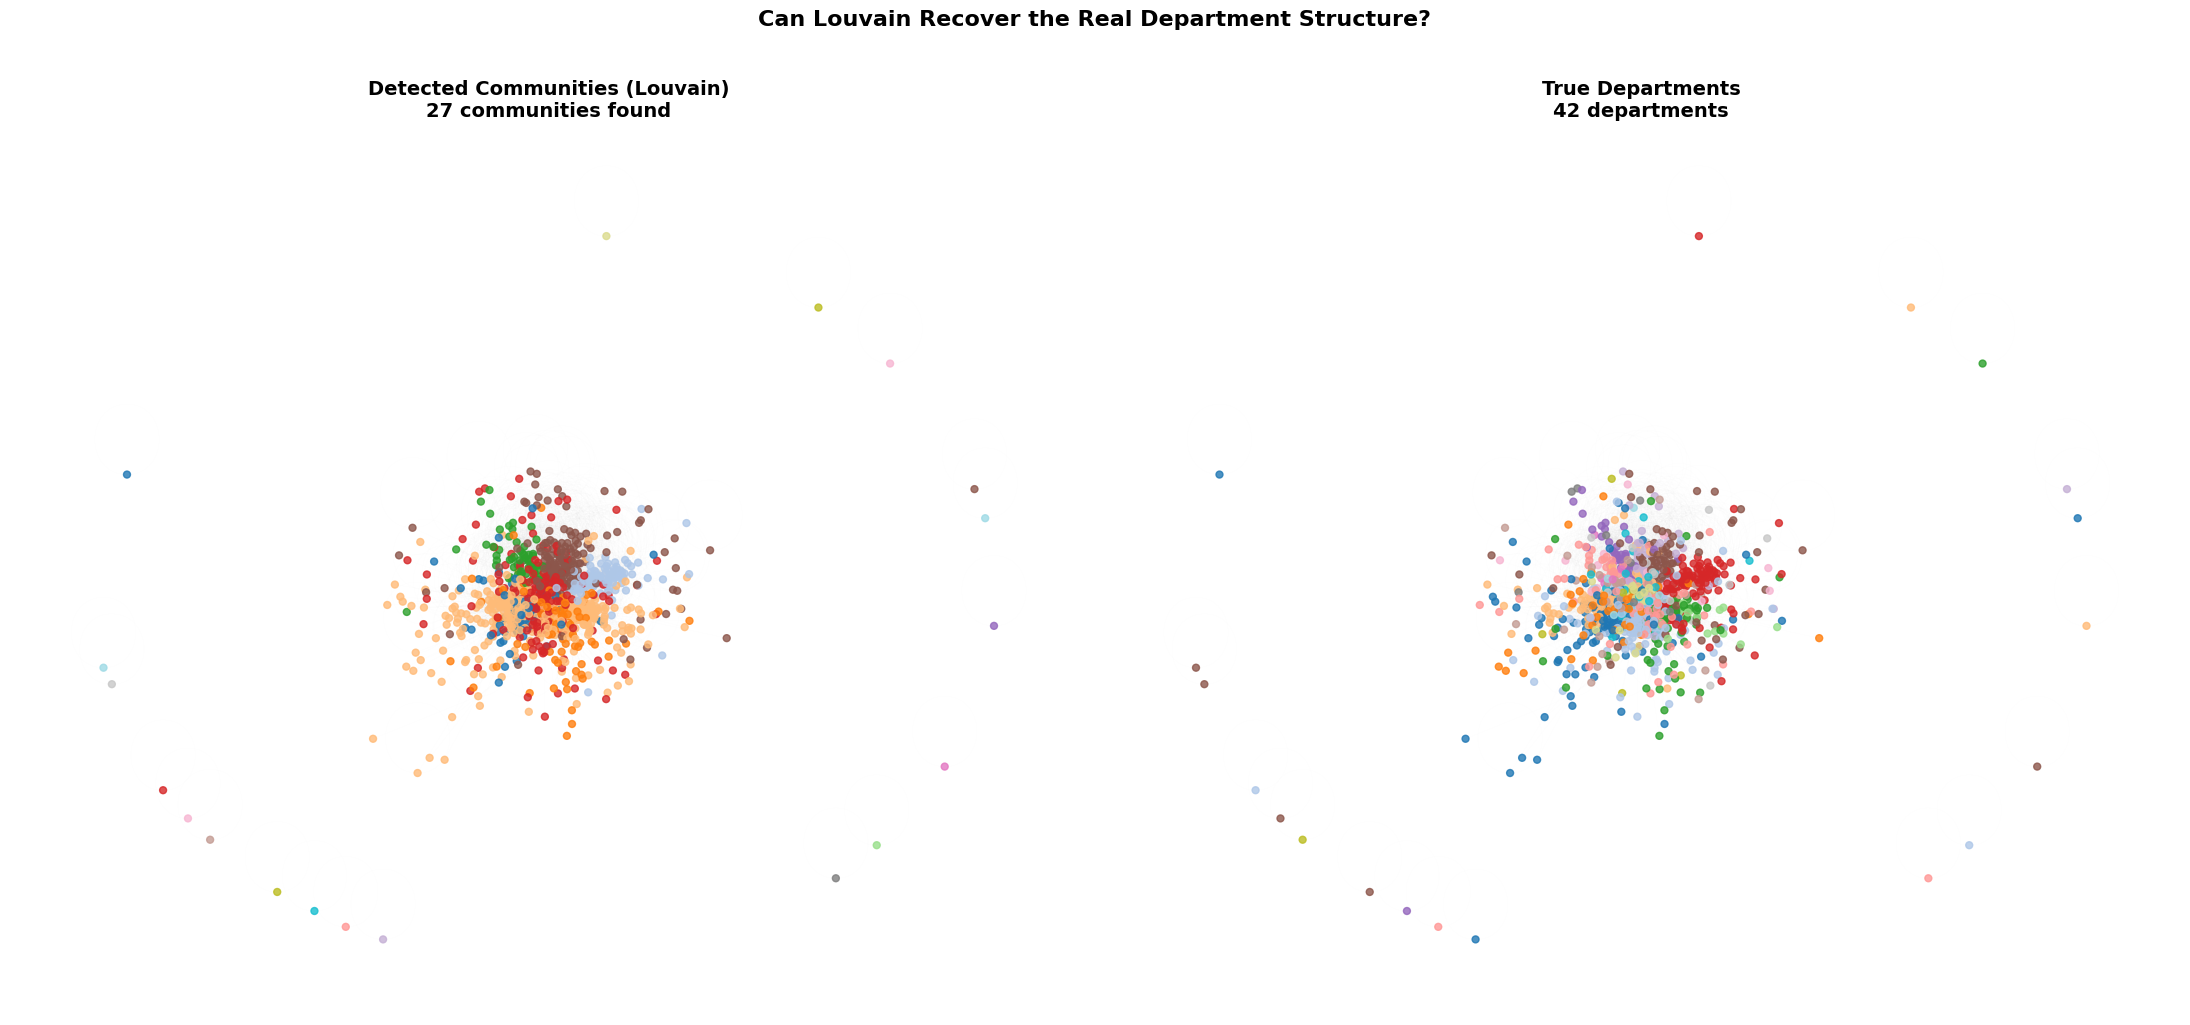


Dominant department analysis for top 3 communities:

  Community 5 (221 members):
    Dominant department: Dept 4 (64 members, 29.0%)
    Top 3 departments: Dept 4(64)  Dept 7(47)  Dept 0(47)  

  Community 9 (194 members):
    Dominant department: Dept 4 (35 members, 18.0%)
    Top 3 departments: Dept 4(35)  Dept 8(19)  Dept 36(15)  

  Community 13 (148 members):
    Dominant department: Dept 21 (53 members, 35.8%)
    Top 3 departments: Dept 21(53)  Dept 19(28)  Dept 22(18)  

  COMMUNITY DETECTION vs GROUND TRUTH
  Adjusted Rand Index (ARI):       0.2837
  Normalized Mutual Info (NMI):    0.5592

  ARI interpretation:
    0.0 = random chance
    1.0 = perfect match
    Our score: 0.284 → Weak agreement!

  💡 The Louvain algorithm can partially recover the real
     department structure just from email patterns alone!


In [26]:
# ============================================
# EXERCISE 4: Community Detection vs Ground Truth
# ============================================

import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Correct Louvain import
try:
    import community.community_louvain as community_louvain
except ImportError:
    import community as community_louvain

# Task 1: Run Louvain on the undirected email network
partition_email = community_louvain.best_partition(G_email, random_state=42)

# Task 2: Count detected communities and calculate modularity
n_detected = len(set(partition_email.values()))
n_real = len(set(dept_labels.values()))  # Number of real departments
modularity_email = community_louvain.modularity(partition_email, G_email)

print(f"Detected communities (Louvain): {n_detected}")
print(f"Real departments:               {n_real}")
print(f"Modularity:                     {modularity_email:.4f}")

# Task 3: Side-by-side visualization
print("Computing layout (this may take a moment)...")
pos_email = nx.spring_layout(G_email, seed=42, k=0.08, iterations=50)

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

# Left: Detected communities
colors_detected = [partition_email.get(n, -1) for n in G_email.nodes()]
nx.draw_networkx_edges(
    G_email, pos_email,
    edge_color='#D5D8DC', width=0.1, alpha=0.1, ax=axes[0]
)
nx.draw_networkx_nodes(
    G_email, pos_email,
    node_color=colors_detected, cmap=plt.cm.tab20,
    node_size=25, alpha=0.8, ax=axes[0]
)
axes[0].set_title(
    f'Detected Communities (Louvain)\n{n_detected} communities found',
    fontsize=14, fontweight='bold'
)
axes[0].axis('off')

# Right: True departments
colors_true = [dept_labels.get(n, -1) for n in G_email.nodes()]
nx.draw_networkx_edges(
    G_email, pos_email,
    edge_color='#D5D8DC', width=0.1, alpha=0.1, ax=axes[1]
)
nx.draw_networkx_nodes(
    G_email, pos_email,
    node_color=colors_true, cmap=plt.cm.tab20,
    node_size=25, alpha=0.8, ax=axes[1]
)
axes[1].set_title(
    f'True Departments\n{n_real} departments',
    fontsize=14, fontweight='bold'
)
axes[1].axis('off')

plt.suptitle(
    'Can Louvain Recover the Real Department Structure?',
    fontsize=16, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

# Task 4: Dominant department per community
comm_sizes_email = Counter(partition_email.values())
top3_comms = [c for c, _ in comm_sizes_email.most_common(3)]

print("\nDominant department analysis for top 3 communities:")
print("=" * 60)

for comm_id in top3_comms:
    comm_nodes = [n for n, c in partition_email.items() if c == comm_id]
    comm_depts = [dept_labels.get(n, -1) for n in comm_nodes]

    dept_counter = Counter(comm_depts)
    dominant_dept, dominant_count = dept_counter.most_common(1)[0]
    pct = dominant_count / len(comm_nodes) * 100

    print(f"\n  Community {comm_id} ({len(comm_nodes)} members):")
    print(f"    Dominant department: Dept {dominant_dept} ({dominant_count} members, {pct:.1f}%)")
    print("    Top 3 departments: ", end="")
    for dept, cnt in dept_counter.most_common(3):
        print(f"Dept {dept}({cnt})", end="  ")
    print()

# Task 5: Adjusted Rand Index (ARI) and NMI

# Build aligned label lists
common_nodes = [n for n in G_email.nodes() if n in dept_labels and n in partition_email]
true_labels = [dept_labels[n] for n in common_nodes]
pred_labels = [partition_email[n] for n in common_nodes]

ari = adjusted_rand_score(true_labels, pred_labels)
nmi = normalized_mutual_info_score(true_labels, pred_labels)

print(f"\n{'='*50}")
print(f"  COMMUNITY DETECTION vs GROUND TRUTH")
print(f"{'='*50}")
print(f"  Adjusted Rand Index (ARI):       {ari:.4f}")
print(f"  Normalized Mutual Info (NMI):    {nmi:.4f}")
print(f"{'='*50}")

print(f"\n  ARI interpretation:")
print("    0.0 = random chance")
print("    1.0 = perfect match")
print(f"    Our score: {ari:.3f} → "
      f"{'Strong' if ari > 0.5 else 'Moderate' if ari > 0.3 else 'Weak'} agreement!")

print("\n  💡 The Louvain algorithm can partially recover the real")
print("     department structure just from email patterns alone!")

In [ ]:
# ══════════════════════════════════════════
# SOLUTION — Exercise 4
# ══════════════════════════════════════════

# Task 1 & 2: Run Louvain
partition_email = community_louvain.best_partition(G_email, random_state=42)
n_detected = len(set(partition_email.values()))
n_real = len(set(dept_labels.values()))
modularity_email = community_louvain.modularity(partition_email, G_email)

print(f"Detected communities (Louvain): {n_detected}")
print(f"Real departments:               {n_real}")
print(f"Modularity:                     {modularity_email:.4f}")

In [ ]:
# Task 3: Side-by-side visualization
print("Computing layout...")
pos_email = nx.spring_layout(G_email, seed=42, k=0.08, iterations=50)

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

# Left: Detected communities
colors_detected = [partition_email.get(n, -1) for n in G_email.nodes()]
nx.draw_networkx_edges(G_email, pos_email, edge_color='#D5D8DC', width=0.1,
                       alpha=0.1, ax=axes[0])
nx.draw_networkx_nodes(G_email, pos_email, node_color=colors_detected,
                       cmap=plt.cm.tab20, node_size=25, alpha=0.8, ax=axes[0])
axes[0].set_title(f'Detected Communities (Louvain)\n{n_detected} communities found',
                  fontsize=14, fontweight='bold')
axes[0].axis('off')

# Right: True departments
colors_true = [dept_labels.get(n, -1) for n in G_email.nodes()]
nx.draw_networkx_edges(G_email, pos_email, edge_color='#D5D8DC', width=0.1,
                       alpha=0.1, ax=axes[1])
nx.draw_networkx_nodes(G_email, pos_email, node_color=colors_true,
                       cmap=plt.cm.tab20, node_size=25, alpha=0.8, ax=axes[1])
axes[1].set_title(f'True Departments\n{n_real} departments',
                  fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.suptitle('Can Louvain Recover the Real Department Structure?',
            fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Task 4: Dominant department per community
comm_sizes_email = Counter(partition_email.values())
top3_comms = [c for c, _ in comm_sizes_email.most_common(3)]

print("\nDominant department analysis for top 3 communities:")
print("=" * 60)

for comm_id in top3_comms:
    comm_nodes = [n for n, c in partition_email.items() if c == comm_id]
    comm_depts = [dept_labels.get(n, -1) for n in comm_nodes]
    dept_counter = Counter(comm_depts)
    dominant_dept, dominant_count = dept_counter.most_common(1)[0]
    pct = dominant_count / len(comm_nodes) * 100

    print(f"\n  Community {comm_id} ({len(comm_nodes)} members):")
    print(f"    Dominant department: Dept {dominant_dept} ({dominant_count} members, {pct:.1f}%)")
    print(f"    Top 3 departments: ", end="")
    for dept, cnt in dept_counter.most_common(3):
        print(f"Dept {dept}({cnt})", end="  ")
    print()

In [ ]:
# Task 5: Adjusted Rand Index (ARI)
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Build aligned label lists
common_nodes = [n for n in G_email.nodes() if n in dept_labels and n in partition_email]
true_labels = [dept_labels[n] for n in common_nodes]
pred_labels = [partition_email[n] for n in common_nodes]

ari = adjusted_rand_score(true_labels, pred_labels)
nmi = normalized_mutual_info_score(true_labels, pred_labels)

print(f"\n{'='*50}")
print(f"  COMMUNITY DETECTION vs GROUND TRUTH")
print(f"{'='*50}")
print(f"  Adjusted Rand Index (ARI):      {ari:.4f}")
print(f"  Normalized Mutual Info (NMI):    {nmi:.4f}")
print(f"{'='*50}")
print(f"\n  ARI interpretation:")
print(f"    0.0 = random chance")
print(f"    1.0 = perfect match")
print(f"    Our score: {ari:.3f} → {'Strong' if ari > 0.5 else 'Moderate' if ari > 0.3 else 'Weak'} agreement!")
print(f"\n  💡 The Louvain algorithm can partially recover the real")
print(f"     department structure just from email patterns alone!")

---
## ✏️ Exercise 5: Comparative Analysis & Reflection (Hard)

Now let's put it all together and compare the two networks we've studied.

**Tasks:**
1. Fill in the comparison table below by computing the metrics for the Email network (Facebook metrics are provided)
2. Generate an equivalent random graph for the Email network and compare clustering coefficients
3. Is the Email network also a small-world network? Justify your answer.
4. **Reflection questions** (write your answers in a text cell):
   - Why does the email network have a different community structure than the Facebook network?
   - What real-world factors might explain the differences in clustering?
   - If you were the institution's director, what insights from this analysis would be actionable?

In [33]:
# ============================================
# EXERCISE 5: Comparative Analysis
# ============================================

import os
import networkx as nx
import urllib.request
import gzip
import numpy as np # Ensure numpy is imported for random graph and other calculations

# --- Ensure Facebook data is available and G_fb is defined ---
url_fb = "https://snap.stanford.edu/data/facebook_combined.txt.gz"
fb_gz = "facebook_combined.txt.gz"
fb_txt = "facebook_combined.txt"

if not os.path.exists(fb_txt):
    print("Downloading Facebook ego network dataset from SNAP...")
    urllib.request.urlretrieve(url_fb, fb_gz)
    with gzip.open(fb_gz, 'rb') as f_in:
        with open(fb_txt, 'wb') as f_out:
            f_out.write(f_in.read())
    print("✅ Download complete!")
else:
    print("✅ Facebook file already exists.")

# Load into NetworkX
G_fb = nx.read_edgelist(fb_txt, nodetype=int)

# -----------------------------
# Helper functions
# -----------------------------
def get_lcc(G):
    """Return the largest connected component of G."""
    if nx.is_connected(G):
        return G.copy()
    largest_cc = max(nx.connected_components(G), key=len)
    return G.subgraph(largest_cc).copy()

# The resolve_facebook_graph function is no longer needed as G_fb is now explicitly loaded above.

# -----------------------------
# Resolve required graphs (G_email check still needed)
# -----------------------------
if 'G_email' not in globals():
    raise NameError("Email graph 'G_email' is not defined. Please load it first by running previous cells.")

# -----------------------------
# Correct Louvain import
# -----------------------------
try:
    import community.community_louvain as community_louvain
except ImportError:
    import community as community_louvain

# -----------------------------
# Facebook metrics
# -----------------------------
G_fb_lcc = get_lcc(G_fb)

fb_nodes = G_fb_lcc.number_of_nodes()
fb_edges = G_fb_lcc.number_of_edges()
fb_density = nx.density(G_fb_lcc)
fb_avg_degree = 2 * fb_edges / fb_nodes
fb_avg_clustering = nx.average_clustering(G_fb_lcc)
fb_avg_path = nx.average_shortest_path_length(G_fb_lcc)
fb_diameter = nx.diameter(G_fb_lcc)

fb_partition = community_louvain.best_partition(G_fb_lcc, random_state=42)
fb_n_communities = len(set(fb_partition.values()))
fb_modularity = community_louvain.modularity(fb_partition, G_fb_lcc)

# -----------------------------
# Email metrics
# -----------------------------
G_email_lcc = get_lcc(G_email)

email_nodes = G_email_lcc.number_of_nodes()
email_edges = G_email_lcc.number_of_edges()
email_density = nx.density(G_email_lcc)
email_avg_degree = 2 * email_edges / email_nodes
email_clustering = nx.average_clustering(G_email_lcc)
email_avg_path = nx.average_shortest_path_length(G_email_lcc)
email_diameter = nx.diameter(G_email_lcc)

partition_email = community_louvain.best_partition(G_email_lcc, random_state=42)
n_detected = len(set(partition_email.values()))
modularity_email = community_louvain.modularity(partition_email, G_email_lcc)

# -----------------------------
# Comparison table
# -----------------------------
print(f"\n{'='*70}")
print(f"  NETWORK COMPARISON: Facebook vs Email-Eu-Core")
print(f"{'='*70}")
print(f"  {'Metric':<35} {'Facebook':>14} {'Email':>14}")
print(f"  {'-'*70}")
print(f"  {'Nodes':<35} {fb_nodes:>14,} {email_nodes:>14,}")
print(f"  {'Edges':<35} {fb_edges:>14,} {email_edges:>14,}")
print(f"  {'Density':<35} {fb_density:>14.5f} {email_density:>14.5f}")
print(f"  {'Avg. Degree':<35} {fb_avg_degree:>14.1f} {email_avg_degree:>14.1f}")
print(f"  {'Avg. Clustering':<35} {fb_avg_clustering:>14.4f} {email_clustering:>14.4f}")
print(f"  {'Avg. Shortest Path':<35} {fb_avg_path:>14.4f} {email_avg_path:>14.4f}")
print(f"  {'Diameter':<35} {fb_diameter:>14} {email_diameter:>14}")
print(f"  {'Communities (Louvain)':<35} {fb_n_communities:>14} {n_detected:>14}")
print(f"  {'Modularity':<35} {fb_modularity:>14.4f} {modularity_email:>14.4f}")
print(f"{'='*70}")

# -----------------------------
# Random graph comparison and small-world test
# -----------------------------
n_e = G_email_lcc.number_of_nodes()
m_e = G_email_lcc.number_of_edges()
G_rand_email = nx.gnm_random_graph(n_e, m_e, seed=42)

if not nx.is_connected(G_rand_email):
    rand_lcc = max(nx.connected_components(G_rand_email), key=len)
    G_rand_email = G_rand_email.subgraph(rand_lcc).copy()

rand_clustering = nx.average_clustering(G_rand_email)
rand_avg_path = nx.average_shortest_path_length(G_rand_email)

c_ratio = email_clustering / rand_clustering if rand_clustering > 0 else float('inf')
l_ratio = email_avg_path / rand_avg_path

print(f"\n{'='*60}")
print(f"  SMALL-WORLD TEST: Email-Eu-Core")
print(f"{'='*60}")
print(f"  {'Metric':<30} {'Email (real)':>14} {'Random':>14}")
print(f"  {'-'*60}")
print(f"  {'Avg. Clustering':<30} {email_clustering:>14.4f} {rand_clustering:>14.4f}")
print(f"  {'Avg. Shortest Path':<30} {email_avg_path:>14.4f} {rand_avg_path:>14.4f}")

print(f"\n  Clustering ratio (C_real / C_random): {c_ratio:.1f}x")
print(f"  Path length ratio (L_real / L_random): {l_ratio:.2f}x")

is_sw = c_ratio > 5 and l_ratio < 3
print(f"\n  Small-world? {'YES' if is_sw else 'NO'}")
if is_sw:
    print(f"    Clustering is {c_ratio:.0f}x higher than random (much higher),")
    print(f"    but paths are only {l_ratio:.1f}x longer (comparable).")
print(f"{'='*60}")

✅ Download complete!

  NETWORK COMPARISON: Facebook vs Email-Eu-Core
  Metric                                    Facebook          Email
  ----------------------------------------------------------------------
  Nodes                                        4,039            986
  Edges                                       88,234         16,687
  Density                                    0.01082        0.03436
  Avg. Degree                                   43.7           33.8
  Avg. Clustering                             0.6055         0.4071
  Avg. Shortest Path                          3.6925         2.5869
  Diameter                                         8              7
  Communities (Louvain)                           15              8
  Modularity                                  0.8349         0.4227

  SMALL-WORLD TEST: Email-Eu-Core
  Metric                           Email (real)         Random
  ------------------------------------------------------------
  Avg. Clusterin

In [ ]:
# ══════════════════════════════════════════
# SOLUTION — Exercise 5
# ══════════════════════════════════════════

# Get largest connected component for Email
if not nx.is_connected(G_email):
    largest_cc_email = max(nx.connected_components(G_email), key=len)
    G_email_lcc = G_email.subgraph(largest_cc_email).copy()
else:
    G_email_lcc = G_email

# Compute Email metrics
email_clustering = nx.average_clustering(G_email_lcc)
email_avg_path = nx.average_shortest_path_length(G_email_lcc)
email_diameter = nx.diameter(G_email_lcc)
email_avg_degree = 2 * G_email_lcc.number_of_edges() / G_email_lcc.number_of_nodes()

# Comparison table
print(f"\n{'='*70}")
print(f"  NETWORK COMPARISON: Facebook vs Email-Eu-Core")
print(f"{'='*70}")
print(f"  {'Metric':<35} {'Facebook':>14} {'Email':>14}")
print(f"  {'-'*63}")
print(f"  {'Nodes':<35} {G_fb.number_of_nodes():>14,} {G_email_lcc.number_of_nodes():>14,}")
print(f"  {'Edges':<35} {G_fb.number_of_edges():>14,} {G_email_lcc.number_of_edges():>14,}")
print(f"  {'Density':<35} {nx.density(G_fb):>14.5f} {nx.density(G_email_lcc):>14.5f}")
print(f"  {'Avg. Degree':<35} {avg_degree:>14.1f} {email_avg_degree:>14.1f}")
print(f"  {'Avg. Clustering':<35} {avg_clustering:>14.4f} {email_clustering:>14.4f}")
print(f"  {'Avg. Shortest Path':<35} {avg_path:>14.4f} {email_avg_path:>14.4f}")
print(f"  {'Diameter':<35} {diameter:>14} {email_diameter:>14}")
print(f"  {'Communities (Louvain)':<35} {n_communities:>14} {n_detected:>14}")
print(f"  {'Modularity':<35} {modularity:>14.4f} {modularity_email:>14.4f}")
print(f"{'='*70}")

In [ ]:
# Task 2 & 3: Random graph comparison and small-world test
n_e = G_email_lcc.number_of_nodes()
m_e = G_email_lcc.number_of_edges()
G_rand_email = nx.gnm_random_graph(n_e, m_e, seed=42)

# Ensure it's connected (for path length calculation)
if not nx.is_connected(G_rand_email):
    rand_lcc = max(nx.connected_components(G_rand_email), key=len)
    G_rand_email = G_rand_email.subgraph(rand_lcc).copy()

rand_clustering = nx.average_clustering(G_rand_email)
rand_avg_path = nx.average_shortest_path_length(G_rand_email)

# Small-world ratios
c_ratio = email_clustering / rand_clustering if rand_clustering > 0 else float('inf')
l_ratio = email_avg_path / rand_avg_path

print(f"\n{'='*60}")
print(f"  SMALL-WORLD TEST: Email-Eu-Core")
print(f"{'='*60}")
print(f"  {'Metric':<30} {'Email (real)':>14} {'Random':>14}")
print(f"  {'-'*58}")
print(f"  {'Avg. Clustering':<30} {email_clustering:>14.4f} {rand_clustering:>14.4f}")
print(f"  {'Avg. Shortest Path':<30} {email_avg_path:>14.4f} {rand_avg_path:>14.4f}")
print(f"\n  Clustering ratio (C_real / C_random): {c_ratio:.1f}x")
print(f"  Path length ratio (L_real / L_random): {l_ratio:.2f}x")

is_sw = c_ratio > 5 and l_ratio < 3
print(f"\n  Small-world? {'✅ YES!' if is_sw else '❌ No'}")
if is_sw:
    print(f"    Clustering is {c_ratio:.0f}x higher than random (much higher),")
    print(f"    but paths are only {l_ratio:.1f}x longer (comparable).")
print(f"{'='*60}")

### ✍️ Write Your Reflection Below

Double-click this cell to edit and write your answers:

**Q1: Why does the email network have a different community structure than the Facebook network?**

*Your answer here...*

**Q2: What real-world factors might explain the differences in clustering?**

*Your answer here...*

**Q3: If you were the institution's director, what insights from this analysis would be actionable?**

*Your answer here...*

---
## 📚 Summary & References

### What We Learned

| Concept | Facebook Application | Email Application |
|---------|---------------------|-------------------|
| Degree Distribution | Power-law; hubs with 300+ friends | In/out-degree; heavy senders & receivers |
| Centrality | Bridge nodes between social circles | Cross-department communicators |
| Community Detection | Discovered natural social circles | Recovered ~department structure from emails |
| Small-World Property | High clustering + short paths | Same property in organizational setting |

### Dataset Citations

1. **Facebook Ego Networks:**
   > J. McAuley and J. Leskovec. *Learning to Discover Social Circles in Ego Networks.* NIPS, 2012.

2. **Email-Eu-Core:**
   > H. Yin, A. R. Benson, J. Leskovec, and D. F. Gleich. *Local Higher-order Graph Clustering.* KDD, 2017.
   >
   > A. Leskovec, J. Kleinberg, and C. Faloutsos. *Graph Evolution: Densification and Shrinking Diameters.* ACM TKDD, 2007.

3. **SNAP Dataset Collection:**
   > J. Leskovec and A. Krevl. *SNAP Datasets: Stanford Large Network Dataset Collection.* http://snap.stanford.edu/data, 2014.

### Further Reading
- [Network Science](http://networksciencebook.com/) — free online textbook by Albert-László Barabási
- [NetworkX Documentation](https://networkx.org/documentation/stable/)
- [SNAP Stanford Datasets](https://snap.stanford.edu/data/) — more datasets to explore